In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

salary_data = pd.read_csv("salary_prediction_dataset.csv")

# Cleaning
salary_data.dropna(inplace=True)
salary_data.drop_duplicates(inplace=True)

# Encoding
salary_data = pd.get_dummies(
    salary_data,
    columns=['EDUCATION','JOBROLE','LOCATION','REMOTEWORK'],
    drop_first=True
)

# Features / Target
X = salary_data.drop(columns=['SALARY'])
y = salary_data['SALARY']

training_columns = X.columns

# Split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train,y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test,predictions)
r2 = r2_score(y_test,predictions)

print("MSE:", mse)
print("R²:", r2)

MSE: 3.287973213498814e-17
R²: 1.0


In [59]:
# new predictions
new_person = pd.DataFrame({
    'EXPERIENCE':[5],
    'AGE':[29],
    'SKILLS':[8],
    'EDUCATION':['Degree'],
    'JOBROLE':['Developer'],
    'LOCATION':['Lagos'],
    'REMOTEWORK':['Yes']
})

In [60]:
# encode
new_person = pd.get_dummies(new_person)

In [65]:
new_person = pd.DataFrame({
    'EXPERIENCE':[5],
    'AGE':[29],
    'SKILLS':[8],
    'EDUCATION':['Degree'],
    'JOBROLE':['Developer'],
    'LOCATION':['Lagos'],
    'REMOTEWORK':['Yes']
})

new_person = pd.get_dummies(new_person)
# match training columns
new_person = new_person.reindex(columns=training_columns, fill_value=0)
# new predictions
salary_prediction = model.predict(new_person)

print("Predicted Salary: ₦{:,.0f}".format(salary_prediction[0]))

Predicted Salary: ₦1,011,500


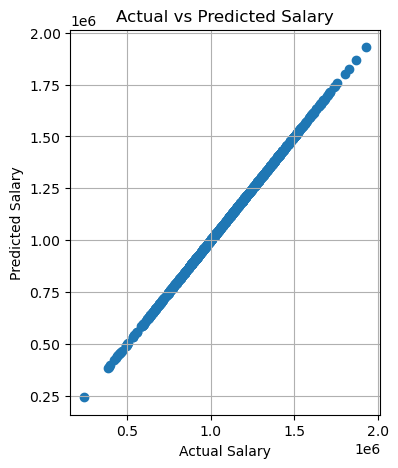

In [78]:
# plotting graph
plt.figure(figsize=(4,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.grid(True)
plt.show()

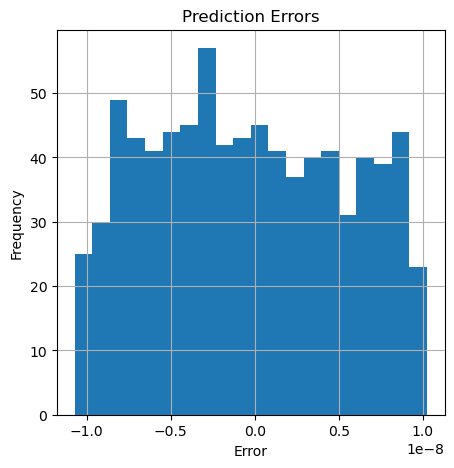

In [74]:
# error Distributions
errors = y_test - predictions

plt.figure(figsize=(5,5))
plt.hist(errors,bins=20)
plt.title("Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

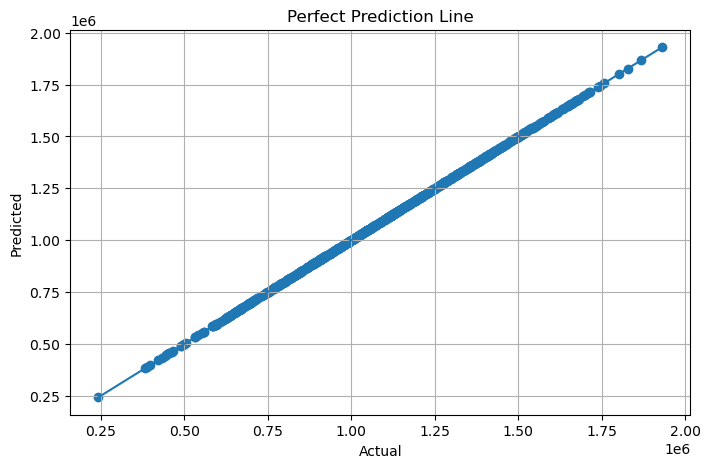

In [75]:
# straight line comparison
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Perfect Prediction Line")
plt.grid(True)
plt.show()

In [80]:
# save joblic model
joblib.dump(model, "salary_model.pkl")
joblib.dump(training_columns, "training_columns.pkl")

['training_columns.pkl']

In [81]:
print("Model saved successfully")

Model saved successfully
